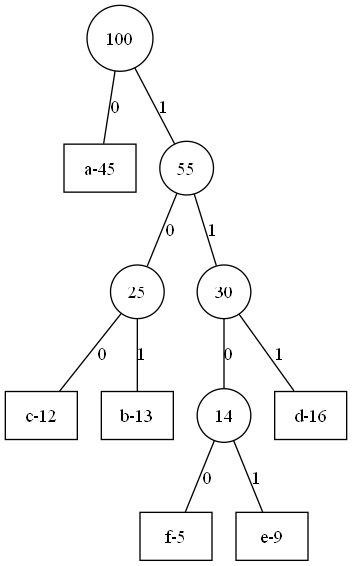

In [ ]:
import os
import heapq
from graphviz import Digraph
from IPython.display import Image, display


class Node:
    def __init__(self, char, freq):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq

    def __repr__(self):
        if self.char:
            return f"{self.char}-{self.freq}"
        else:
            return f"{self.freq}"


def HUFFMAN(C):
    Q = []  # 构建优先队列
    for i in range(len(C)):
        heapq.heappush(Q, Node(C[i][0], C[i][1]))

    # 贪心合并最小结点
    for i in range(len(C) - 1):
        z = Node(None, None)
        z.left = x = heapq.heappop(Q)
        z.right = y = heapq.heappop(Q)
        z.freq = x.freq + y.freq
        heapq.heappush(Q, z)

    return heapq.heappop(Q)


def draw_tree(dot=None, node=None, name=""):
    """绘制二叉树"""
    if dot is None:
        # 初始化图
        dot = Digraph()
        dot.attr("edge", dir="none")

        # 递归添加每层的结点和边
        draw_tree(dot, node)

        # 渲染并显示图像
        dot.render("huffman", format="png", cleanup=True)
        display(Image("huffman.png"))
        os.remove("huffman.png")
    else:
        if node.left and node.right:
            dot.node(name, f"{node}", shape="circle")
            dot.edge(name, name + "l", "0", constraint="true")
            dot.edge(name, name + "r", "1", constraint="true")
            draw_tree(dot, node.left, name + "l")
            draw_tree(dot, node.right, name + "r")
        else:
            dot.node(name, f"{node}", shape="rect")


C = [("a", 45), ("b", 13), ("c", 12), ("d", 16), ("e", 9), ("f", 5)]
draw_tree(node=HUFFMAN(C))